In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Making fig 1 - Curvature

In [4]:
grand_folder = '18_06_TESTS/'

iso_up      = np.load(grand_folder + 'iso_up_20/data.pkl', allow_pickle=True)
iso_down    = np.load(grand_folder + 'iso_down_20/data.pkl', allow_pickle=True)
pringle_du  = np.load(grand_folder + 'pringle_downup_20/data.pkl', allow_pickle=True)
pringle_ud  = np.load(grand_folder + 'pringle_updown_20/data.pkl', allow_pickle=True)

In [10]:
iso_up_last_frame_x = iso_up['x'][-2]
iso_up_last_frame_p = iso_up['p'][-2]
iso_up_last_frame_q = iso_up['q'][-2]

In [ ]:
from pathlib import Path

import pyvista as pv
from IPython.display import Image, display
from scipy.spatial import cKDTree

# --- settings ---
WINDOW_SIZE = (900, 900)
CMAP = "viridis_r"  # bright colors near camera, darker farther away
ELEVATION, AZIMUTH = 35, 45
OUTPUT_PREFIX = "fig1_iso_up_spheres"
SPHERE_RADIUS = 1  # auto from nearest-neighbor spacing
SPHERE_RESOLUTION = 24  # lower = smaller SVG, higher = smoother spheres
AMBIENT, DIFFUSE = 0.18, 0.82  # headlight shading for vector export


def rgba_to_hex(rgb):
    r, g, b = (np.clip(rgb, 0, 1) * 255).astype(int)
    return f"#{r:02x}{g:02x}{b:02x}"


def world_to_display(plotter, points):
    renderer = plotter.renderer
    _, height = plotter.window_size
    out = np.empty((len(points), 3), dtype=float)
    for i, pt in enumerate(points):
        renderer.SetWorldPoint(float(pt[0]), float(pt[1]), float(pt[2]), 1.0)
        renderer.WorldToDisplay()
        dx, dy, dz = renderer.GetDisplayPoint()
        out[i] = (dx, height - 1 - dy, dz)
    return out


def shaded_face_colors(mesh, base_rgb, cam_pos):
    mesh = mesh.compute_normals(cell_normals=True, inplace=False)
    normals = np.asarray(mesh.cell_normals)
    centers = np.asarray(mesh.cell_centers().points)
    light_dirs = cam_pos - centers
    light_dirs /= np.linalg.norm(light_dirs, axis=1, keepdims=True) + 1e-12
    ndotl = np.clip((normals * light_dirs).sum(axis=1), 0.0, 1.0)
    intensity = AMBIENT + DIFFUSE * ndotl
    return np.clip(base_rgb * intensity[:, None], 0.0, 1.0)


def export_shaded_mesh_svg(filename, plotter, sphere_meshes, base_colors, cam_pos, width, height):
    """Scalable vector SVG: each triangle keeps its own shaded fill color."""
    triangles = []
    for mesh, base_rgb in zip(sphere_meshes, base_colors):
        face_colors = shaded_face_colors(mesh, base_rgb, cam_pos)
        screen = world_to_display(plotter, mesh.points)
        faces = mesh.faces.reshape(-1, 4)[:, 1:4]
        for fi, tri in enumerate(faces):
            pts = screen[tri, :2]
            depth = screen[tri, 2].mean()
            path = (
                f"M {pts[0, 0]:.4f},{pts[0, 1]:.4f} "
                f"L {pts[1, 0]:.4f},{pts[1, 1]:.4f} "
                f"L {pts[2, 0]:.4f},{pts[2, 1]:.4f} Z"
            )
            triangles.append((depth, path, rgba_to_hex(face_colors[fi])))

    triangles.sort(key=lambda item: item[0], reverse=True)
    lines = [
        '<?xml version="1.0" encoding="UTF-8"?>',
        f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 {width} {height}">',
    ]
    for _, path, color in triangles:
        lines.append(f'<path d="{path}" fill="{color}" stroke="none"/>')
    lines.append("</svg>")
    Path(filename).write_text("\n".join(lines))


x = np.asarray(iso_up_last_frame_x, dtype=float)
center = x.mean(axis=0)

if SPHERE_RADIUS is None:
    dists, _ = cKDTree(x).query(x, k=2)
    SPHERE_RADIUS = 0.35 * dists[:, 1].mean()

pv.global_theme.transparent_background = True
pl = pv.Plotter(window_size=WINDOW_SIZE, off_screen=True)
pl.set_background(None)
pl.show_axes = False

sphere_meshes = []
actors = []
for pos in x:
    sphere = pv.Sphere(
        radius=SPHERE_RADIUS,
        center=pos,
        theta_resolution=SPHERE_RESOLUTION,
        phi_resolution=SPHERE_RESOLUTION,
    )
    sphere_meshes.append(sphere)
    actors.append(
        pl.add_mesh(
            sphere,
            color="white",
            smooth_shading=True,
            specular=0.0,
            diffuse=1.0,
            ambient=AMBIENT,
            lighting=True,
            show_edges=False,
        )
    )

pl.camera.focal_point = center
pl.reset_camera()
dist = np.linalg.norm(np.array(pl.camera.position) - center)
elev = np.radians(ELEVATION)
azim = np.radians(AZIMUTH)
pl.camera.position = center + dist * np.array(
    [np.cos(elev) * np.cos(azim), np.cos(elev) * np.sin(azim), np.sin(elev)]
)
pl.camera.view_up = (0, 0, 1)
pl.camera.zoom(1.0 / (1.0 + 0.165))

cam_pos = np.array(pl.camera_position[0])
distances = np.linalg.norm(x - cam_pos, axis=1)
norm = (distances - distances.min()) / (np.ptp(distances) + 1e-9)
base_colors = plt.get_cmap(CMAP)(norm)[:, :3]

for actor, rgb in zip(actors, base_colors):
    actor.GetProperty().SetColor(*rgb)

pl.render()

w, h = WINDOW_SIZE
png_path = f"{OUTPUT_PREFIX}.png"
svg_path = f"{OUTPUT_PREFIX}.svg"
pl.screenshot(png_path, transparent_background=True)
export_shaded_mesh_svg(svg_path, pl, sphere_meshes, base_colors, cam_pos, w, h)

pl.close()
display(Image(filename=png_path))


In [6]:
# Importing the datasets to plot

grand_folder = 'Figure_data/fig1/'

iso_up      = np.load(grand_folder + 'iso_up_20/data.pkl', allow_pickle=True)
iso_down    = np.load(grand_folder + 'iso_down_20/data.pkl', allow_pickle=True)
pringle_du  = np.load(grand_folder + 'pringle_downup_20/data.pkl', allow_pickle=True)
pringle_ud  = np.load(grand_folder + 'pringle_updown_20/data.pkl', allow_pickle=True)
basecase    = np.load(grand_folder + 'plain_basecase/data.pkl', allow_pickle=True)
aniso_perp   = np.load(grand_folder + 'perp_angle_20/data.pkl', allow_pickle=True)
aniso_par  = np.load(grand_folder + 'par_angle_20/data.pkl', allow_pickle=True)

In [21]:
import pyvista as pv
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import cKDTree

# --- render defaults (shared by all panels) ---
RENDER_SETTINGS = {
    "window_size": (420, 420),
    "cmap": "viridis_r",
    "elevation": 35,
    "azimuth": 45,
    "sphere_radius": None,  # None = auto per dataset
    "sphere_resolution": 128,
    "ambient": 0.18,
    "diffuse": 0.82,
    "zoom_margin": 0.165,
}


def rotate_positions(x, axis="x", degrees=90.0, center=None):
    """Rotate (N, 3) positions by degrees around axis through center."""
    x = np.asarray(x, dtype=float)
    if center is None:
        center = x.mean(axis=0)
    rel = x - center
    rad = np.radians(degrees)
    c, s = np.cos(rad), np.sin(rad)
    if axis == "x":
        rot = np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]])
    elif axis == "y":
        rot = np.array([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]])
    elif axis == "z":
        rot = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])
    else:
        raise ValueError(f"axis must be 'x', 'y', or 'z', got {axis!r}")
    return rel @ rot.T + center


def draw_polarity_arrows(ax, origin, polarity_arrow_len=0.20):
    """ABP (red, up) and PCP (green, -30 deg) from a shared origin."""
    legend_origin = np.asarray(origin, dtype=float)
    abp_vec = np.array([0.0, 1.0])
    ax.add_patch(
        FancyArrowPatch(
            legend_origin,
            legend_origin + abp_vec * polarity_arrow_len,
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.8,
            color="#d62728",
            zorder=10,
        )
    )
    ax.text(
        legend_origin[0] - 0.24,
        legend_origin[1] + 0.5 * polarity_arrow_len,
        "ABP",
        color="#d62728",
        fontsize=11,
        ha="left",
        va="center",
        zorder=10,
    )

    pcp_angle = np.radians(-30)
    pcp_dir = np.array([np.cos(pcp_angle), np.sin(pcp_angle)])
    ax.add_patch(
        FancyArrowPatch(
            legend_origin,
            legend_origin + pcp_dir * polarity_arrow_len,
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.8,
            color="#2ca02c",
            zorder=10,
        )
    )
    ax.text(
        legend_origin[0] + pcp_dir[0] * polarity_arrow_len + 0.03,
        legend_origin[1] + pcp_dir[1] * polarity_arrow_len,
        "PCP",
        color="#2ca02c",
        fontsize=11,
        ha="left",
        va="center",
        zorder=10,
    )


def render_sphere_cluster(x, settings=None):
    """Render one (N, 3) position array to an RGBA image array."""
    settings = {**RENDER_SETTINGS, **(settings or {})}
    x = np.asarray(x, dtype=float)
    rotation = settings.get("rotation")
    if rotation:
        x = rotate_positions(x, **rotation)
    center = x.mean(axis=0)

    sphere_radius = settings["sphere_radius"]
    if sphere_radius is None:
        dists, _ = cKDTree(x).query(x, k=2)
        sphere_radius = 0.6 * dists[:, 1].mean()

    window_size = settings["window_size"]
    pv.global_theme.transparent_background = True
    pl = pv.Plotter(window_size=window_size, off_screen=True)
    pl.set_background(None)
    pl.show_axes = False

    actors = []
    for pos in x:
        sphere = pv.Sphere(
            radius=sphere_radius,
            center=pos,
            theta_resolution=settings["sphere_resolution"],
            phi_resolution=settings["sphere_resolution"],
        )
        actors.append(
            pl.add_mesh(
                sphere,
                color="white",
                smooth_shading=True,
                specular=0.0,
                diffuse=1.0,
                ambient=settings["ambient"],
                lighting=True,
                show_edges=False,
            )
        )

    pl.camera.focal_point = center
    pl.reset_camera()
    dist = np.linalg.norm(np.array(pl.camera.position) - center)
    elev = np.radians(settings["elevation"])
    azim = np.radians(settings["azimuth"])
    pl.camera.position = center + dist * np.array(
        [np.cos(elev) * np.cos(azim), np.cos(elev) * np.sin(azim), np.sin(elev)]
    )
    pl.camera.view_up = (0, 0, 1)
    pl.camera.zoom(1.0 / (1.0 + settings["zoom_margin"]))

    cam_pos = np.array(pl.camera_position[0])
    distances = np.linalg.norm(x - cam_pos, axis=1)
    norm = (distances - distances.min()) / (np.ptp(distances) + 1e-9)
    base_colors = plt.get_cmap(settings["cmap"])(norm)[:, :3]
    for actor, rgb in zip(actors, base_colors):
        actor.GetProperty().SetColor(*rgb)

    pl.render()
    img = pl.screenshot(transparent_background=True, return_img=True)
    pl.close()
    return img


def plot_radial_sphere_comparison(
    datasets,
    center_index=6,
    ring_radius=1.55,
    panel_zoom=0.42,
    arrow_inset=0.60,
    arrow_color="#333333",
    arrow_lw=1.4,
    polarity_offset=(0.14, 0.30),
    polarity_arrow_len=0.20,
    figsize=(11, 11),
    output_path=None,
    render_settings=None,
):
    """
    Place 6 datasets on a ring and one in the center; arrows run center -> outer.

    Parameters
    ----------
    datasets : list of 7 dicts
        Each dict must have key "x" with shape (N, 3).
        Optional keys: "label", and per-panel "settings" passed to render_sphere_cluster.
    center_index : int
        Index of the dataset drawn in the middle (default 6 = seventh item).
    arrow_inset : float
        Gap left between each arrow and the panel centers. Larger = shorter arrows.
    """
    if len(datasets) != 7:
        raise ValueError(f"Expected 7 datasets, got {len(datasets)}")

    outer_indices = [i for i in range(7) if i != center_index]
    if len(outer_indices) != 6:
        raise ValueError("center_index must leave exactly 6 outer panels")

    rendered = []
    for i, item in enumerate(datasets):
        panel_settings = {**(render_settings or {}), **item.get("settings", {})}
        rendered.append(render_sphere_cluster(item["x"], panel_settings))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")
    ax.set_aspect("equal")
    ax.axis("off")

    def panel_position(index):
        if index == center_index:
            return np.array([0.0, 0.0])
        ring_slot = outer_indices.index(index)
        angle = np.pi / 2 - ring_slot * 2 * np.pi / 6
        return ring_radius * np.array([np.cos(angle), np.sin(angle)])

    centers = {i: panel_position(i) for i in range(7)}

    for i, img in enumerate(rendered):
        imbox = OffsetImage(img, zoom=panel_zoom)
        imbox.image.axes = ax
        ab = AnnotationBbox(
            imbox,
            centers[i],
            frameon=False,
            pad=0.0,
            box_alignment=(0.5, 0.5),
        )
        ax.add_artist(ab)

        label = datasets[i].get("label")
        if label:
            offset = 0.46 if i == center_index else 0.45 #Text offset down
            ax.text(
                centers[i][0],
                centers[i][1] - offset,
                label,
                ha="center",
                va="top",
                fontsize=12,
            )

    center = centers[center_index]
    for i in outer_indices:
        target = centers[i]
        direction = target - center
        direction = direction / (np.linalg.norm(direction) + 1e-12)
        inset = arrow_inset
        start = center + direction * inset
        end = target - direction * inset
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=arrow_lw,
            color=arrow_color,
            shrinkA=0,
            shrinkB=0,
            zorder=0,
        )
        ax.add_patch(arrow)

    draw_polarity_arrows(
        ax, center + np.array(polarity_offset), polarity_arrow_len=polarity_arrow_len
    )

    pad = ring_radius + 1.0
    ax.set_xlim(-pad, pad)
    ax.set_ylim(-pad, pad)

    if output_path:
        fig.savefig(output_path, dpi=400, transparent=True, bbox_inches="tight", pad_inches=0.1)

    return fig


def plot_dual_basecase_comparison(
    groups,
    corner_radius=1.55,
    upper_base_y=0.42,
    lower_base_y=-0.30,
    lower_corner_shift=0.22,
    panel_zoom=0.42,
    base_panel_scale=0.80,
    arrow_inset=0.55,
    arrow_color="#333333",
    arrow_lw=1.4,
    polarity_offset_right=0.18,
    polarity_y_offset=-0.08,
    polarity_arrow_len=0.20,
    figsize=(11, 11),
    output_path=None,
    render_settings=None,
):
    """
    Two basecases stacked in the centre; each has two arrows to corner transforms.

    Parameters
    ----------
    groups : list of 2 dicts
        Each group has:
          - base: {x, label} — rendered at upper/lower centre
          - transforms: list of 2 dicts with {x, label, corner}
            corner in {"up_left", "up_right", "down_left", "down_right"}
          - rotation: optional {axis, degrees} applied to base + transforms
    """
    if len(groups) != 2:
        raise ValueError(f"Expected 2 groups, got {len(groups)}")
    for gi, group in enumerate(groups):
        if len(group.get("transforms", [])) != 2:
            raise ValueError(f"Group {gi} must have exactly 2 transforms")

    corner_dirs = {
        "up_left": np.array([-1.0, 1.0]) / np.sqrt(2),
        "up_right": np.array([1.0, 1.0]) / np.sqrt(2),
        "down_left": np.array([-1.0, -1.0]) / np.sqrt(2),
        "down_right": np.array([1.0, -1.0]) / np.sqrt(2),
    }
    base_positions = [
        np.array([0.0, upper_base_y]),
        np.array([0.0, lower_base_y]),
    ]

    panel_specs = []
    for group_idx, group in enumerate(groups):
        base_pos = base_positions[group_idx]
        group_rotation = group.get("rotation")
        panel_specs.append(
            {
                "x": group["base"]["x"],
                "label": group["base"].get("label"),
                "position": base_pos,
                "role": "base",
                "settings": {"rotation": group_rotation} if group_rotation else {},
            }
        )
        for tr in group["transforms"]:
            corner = tr["corner"]
            if corner not in corner_dirs:
                raise ValueError(f"Unknown corner {corner!r}")
            tr_settings = dict(tr.get("settings", {}))
            if group_rotation and "rotation" not in tr_settings:
                tr_settings["rotation"] = group_rotation
            corner_pos = corner_radius * corner_dirs[corner]
            if corner in ("down_left", "down_right"):
                corner_pos = corner_pos + np.array([0.0, lower_corner_shift])
            panel_specs.append(
                {
                    "x": tr["x"],
                    "label": tr.get("label"),
                    "position": corner_pos,
                    "role": "transform",
                    "base_position": base_pos,
                    "settings": tr_settings,
                }
            )

    rendered = []
    for spec in panel_specs:
        panel_settings = {**(render_settings or {}), **spec.get("settings", {})}
        rendered.append(render_sphere_cluster(spec["x"], panel_settings))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")
    ax.set_aspect("equal")
    ax.axis("off")

    for spec, img in zip(panel_specs, rendered):
        zoom = panel_zoom * base_panel_scale if spec["role"] == "base" else panel_zoom
        imbox = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(
            imbox,
            spec["position"],
            frameon=False,
            pad=0.0,
            box_alignment=(0.5, 0.5),
        )
        ax.add_artist(ab)

        if spec.get("label"):
            y_off = 0.46 if spec["role"] == "base" else 0.45
            ax.text(
                spec["position"][0],
                spec["position"][1] - y_off,
                spec["label"],
                ha="center",
                va="top",
                fontsize=12,
            )

    upper_base = base_positions[0]
    upper_arrow_lengths = [
        np.linalg.norm(spec["position"] - spec["base_position"]) - 2 * arrow_inset
        for spec in panel_specs
        if spec["role"] == "transform"
        and np.allclose(spec["base_position"], upper_base)
    ]
    fixed_arrow_length = float(np.mean(upper_arrow_lengths))

    for spec in panel_specs:
        if spec["role"] != "transform":
            continue
        start = spec["base_position"]
        end = spec["position"]
        direction = end - start
        direction = direction / (np.linalg.norm(direction) + 1e-12)
        arrow_start = start + direction * arrow_inset
        arrow_end = arrow_start + direction * fixed_arrow_length
        arrow = FancyArrowPatch(
            arrow_start,
            arrow_end,
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=arrow_lw,
            color=arrow_color,
            shrinkA=0,
            shrinkB=0,
            zorder=0,
        )
        ax.add_patch(arrow)

    draw_polarity_arrows(
        ax,
        np.array([
            polarity_offset_right,
            0.5 * (upper_base_y + lower_base_y) + polarity_y_offset,
        ]),
        polarity_arrow_len=polarity_arrow_len,
    )

    pad = corner_radius + 1.0
    ax.set_xlim(-pad, pad)
    ax.set_ylim(-pad, pad)

    if output_path:
        fig.savefig(output_path, dpi=400, transparent=True, bbox_inches="tight", pad_inches=0.1)

    return fig

In [ ]:
# --- configure 7 datasets (replace any entry freely) ---
datasets = [
    {"x": aniso_par["x"][-2], "label": f"$\\alpha_\parallel < 0, \\alpha_\perp = 0$"},
    {"x": pringle_ud["x"][-2], "label": f"$\\alpha_\parallel < 0, \\alpha_\perp > 0$"},
    {"x": pringle_du["x"][-2], "label": f"$\\alpha_\parallel > 0, \\alpha_\perp < 0$"},
    {"x": aniso_perp["x"][-2], "label": f"$\\alpha_\parallel = 0, \\alpha_\perp < 0$"},
    {"x": iso_down["x"][-10], "label": f"$\\alpha_\parallel > 0, \\alpha_\perp > 0$"},
    {"x": iso_up["x"][-2], "label": f"$\\alpha_\parallel < 0, \\alpha_\perp < 0$"},
    {"x": basecase["x"][-2], "label": f"$\\alpha_\parallel = 0, \\alpha_\perp = 0$"},  # center panel (index 6)
]

fig = plot_radial_sphere_comparison(
    datasets,
    center_index=6,
    output_path="fig_radial_sphere_comparison.png",
)
plt.show()

In [17]:
grand_folder = 'Figure_data/fig2/'

plain_basecase    = np.load(grand_folder + 'plain_basecase/data.pkl', allow_pickle=True)
plain_g15      = np.load(grand_folder + 'gamma_1.5/data.pkl', allow_pickle=True)
plain_g06    = np.load(grand_folder + 'gamma_0.66/data.pkl', allow_pickle=True)

cyl_basecase    = np.load(grand_folder + 'cylinder_basecase_par/data.pkl', allow_pickle=True)
cyl_g15      = np.load(grand_folder + 'cylinder_gamma_1.5/data.pkl', allow_pickle=True)
cyl_g06    = np.load(grand_folder + 'cylinder_gamma_0.66/data.pkl', allow_pickle=True)

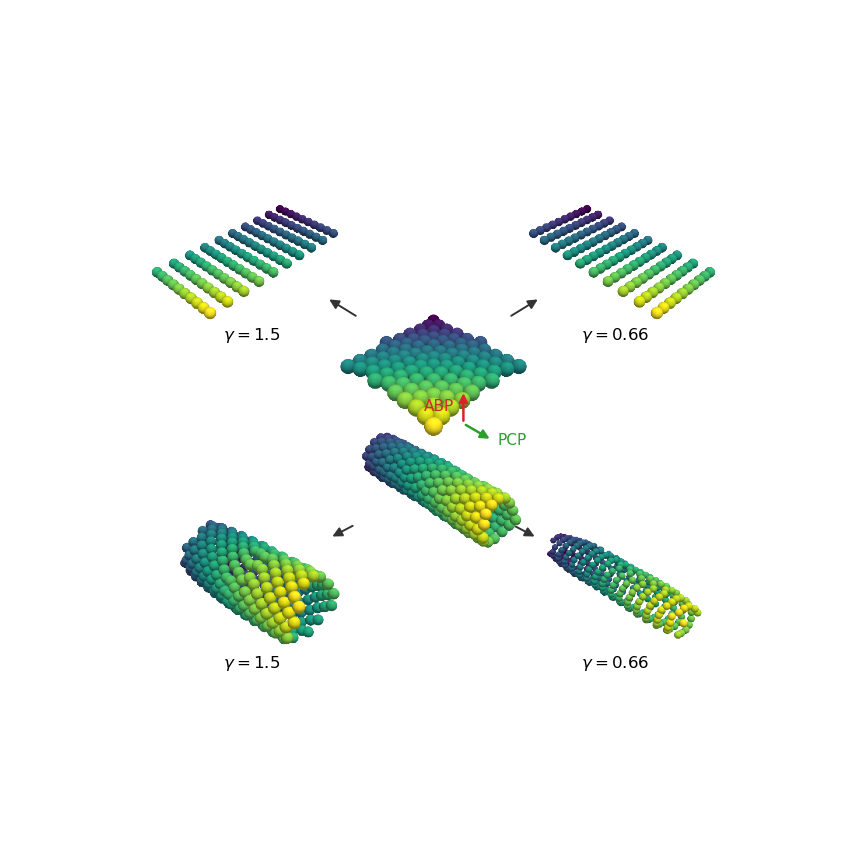

In [22]:
# --- fig 2: two basecases, each with two gamma transforms at corners ---
groups = [
    {
        "base": {"x": plain_basecase["x"][-2]},
        "transforms": [
            {"x": plain_g15["x"][-2], "label": r"$\gamma = 1.5$", "corner": "up_left"},
            {"x": plain_g06["x"][-2], "label": r"$\gamma = 0.66$", "corner": "up_right"},
        ],
    },
    {
        "base": {"x": cyl_basecase["x"][-2]},
        "rotation": {"axis": "x", "degrees": 90},
        "transforms": [
            {"x": cyl_g15["x"][-2], "label": r"$\gamma = 1.5$", "corner": "down_left"},
            {"x": cyl_g06["x"][-2], "label": r"$\gamma = 0.66$", "corner": "down_right"},
        ],
    },
]

fig2 = plot_dual_basecase_comparison(
    groups,
    output_path="fig_dual_basecase_comparison.png",
)
plt.show()
